# RandomForest
### 수업자료 06_machin_learning\09_결정트리와 랜덤포레스트.ipynb에 근거한 Decision Tree와 Random Forest 모델링 

In [ ]:
# 수업자료 06_machin_learning\09_결정트리와 랜덤포레스트.ipynb에 근거한 Decision Tree와 Random Forest 모델링 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import os


In [3]:
df = pd.read_csv("../data/synthetic_customer_churn_100k.csv", skipinitialspace=True)
df.shape

(100000, 9)

In [37]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  str    
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  str    
 6   PaymentMethod   100000 non-null  str    
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 6.9 MB


In [5]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

### EDA 분석 권고에 따라 TotalCharges 음수값을 0으로 대체
### categorical_columns은 label encoding을 하고
### numeric_columns은 scalinf 하지 않음

In [ ]:
# 음수 개수 확인
neg_count = (df['TotalCharges'] < 0).sum()
print(f"음수 개수: {neg_count}개")

# 0으로 교체
df['TotalCharges'] = df['TotalCharges'].apply(lambda x: 0 if x < 0 else x)
neg_count = (df['TotalCharges'] < 0).sum()
print(f"음수 개수: {neg_count}개")

음수 개수: 265개
음수 개수: 0개


In [7]:
# X, y 분리

from sklearn.preprocessing import LabelEncoder
print("분리전:", df.shape)
print(df["Churn"].value_counts())

le = LabelEncoder()
y = le.fit_transform(df["Churn"])
X = df.drop(columns=["CustomerID", "Churn"]) # CustomerID는 의미 없어서 지움
print("분리후:", X.shape, y.shape)
print(pd.Series(y).value_counts())




분리전: (100000, 9)
Churn
No     66856
Yes    33144
Name: count, dtype: int64
분리후: (100000, 7) (100000,)
0    66856
1    33144
Name: count, dtype: int64


In [8]:
# train/val/test set 분리
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0, stratify=y_train) # train 60%, val 20%, test 20% 비율로 생성
    

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

categorical_columns = ['Gender', 'Contract', 'PaymentMethod']
numeric_columns = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'Age']


# ── 1. 범주형 전처리 ──────────────────────────────
cat_imputer = SimpleImputer(strategy="most_frequent")
X_train[categorical_columns] = cat_imputer.fit_transform(X_train[categorical_columns])
X_val[categorical_columns]   = cat_imputer.transform(X_val[categorical_columns])   # ← 추가
X_test[categorical_columns]  = cat_imputer.transform(X_test[categorical_columns])

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train[categorical_columns] = encoder.fit_transform(X_train[categorical_columns])
X_val[categorical_columns]   = encoder.transform(X_val[categorical_columns])       # ← 추가
X_test[categorical_columns]  = encoder.transform(X_test[categorical_columns])

# ── 2. 수치형 전처리 ──────────────────────────────
num_imputer = SimpleImputer(strategy="median")
X_train[numeric_columns] = num_imputer.fit_transform(X_train[numeric_columns])
X_val[numeric_columns]   = num_imputer.transform(X_val[numeric_columns])           # ← 추가
X_test[numeric_columns]  = num_imputer.transform(X_test[numeric_columns])


In [18]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    n_estimators=200, # DecisionTree 개수. (최소 200개)
    max_features=10,  # 지정한 feature수 내에서 random하게 feature들을 선택.
    max_depth=6,      # DecisionTree hyper parameter (모든 Decision Tree 모델들은 동일한 하이퍼파라미터를 가진다..)
    random_state=0,
    n_jobs=-1,        # 개별 DecisionTree 학습, 추론시 병렬 처리 할 때 사용할 프로세서 개수.(각 모델은 독립적으로 학습/추정한다. -1 : 모든 프로세서 다 사용)
)

In [19]:
# 학습(Train)
rfc.fit(X_train, y_train)

# 검증
## 추론: 클래스 결과과
pred_train = rfc.predict(X_train)
pred_val = rfc.predict(X_val)


## 추론: 클래스별 확률 결과
pred_train_proba = rfc.predict_proba(X_train)
pred_val_proba = rfc.predict_proba(X_val)

In [20]:
## 평가
from metrics import print_binary_classification_metrics
print_binary_classification_metrics(
    y_train, pred_train, pred_train_proba[:, 1], "Train set 검증결과"
)

Train set 검증결과
정확도: 0.7640333333333333
재현율: 0.559589661068088
정밀도: 0.6732817037754114
F1 점수: 0.6111934970066458
Average Precision: 0.7054505309683006
ROC-AUC Score: 0.8246630989841477


In [21]:

print_binary_classification_metrics(
    y_val, pred_val, pred_val_proba[:, 1], "Validation set"
)

Validation set
정확도: 0.7578
재현율: 0.5471413486197013
정밀도: 0.6631925397696106
F1 점수: 0.5996032402049926
Average Precision: 0.6699484095180308
ROC-AUC Score: 0.8008489777879978


In [22]:
### fit() 뒤에 feature 중요도 조회
fi = rfc.feature_importances_
fi

array([0.00497687, 0.00087137, 0.33322276, 0.32402971, 0.32772851,
       0.0010632 , 0.00810758])

In [23]:
fi.sum()

np.float64(1.0)

In [26]:
feature_names = categorical_columns + numeric_columns
fi_s = pd.Series(rfc.feature_importances_, index=feature_names).sort_values(ascending=False)


fi_s

PaymentMethod     0.333223
MonthlyCharges    0.327729
Tenure            0.324030
Age               0.008108
Gender            0.004977
TotalCharges      0.001063
Contract          0.000871
dtype: float64

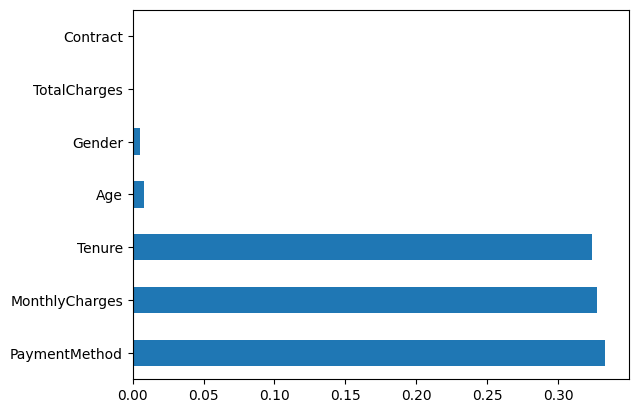

In [27]:
fi_s.plot(kind='barh');

In [29]:
# 10여분 소요
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

model = RandomForestClassifier(random_state=0)
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 3, 6, 10],
    "min_samples_leaf": [1, 2, 4, 6],
}

total = (
    len(param_grid["n_estimators"]) *
    len(param_grid["max_depth"]) *
    len(param_grid["min_samples_leaf"])
)
print(f"총 조합 수: {total}개 × cv=5 = {total * 5}회 학습 예정")

gs = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=['r2', 'neg_mean_squared_error'],
    refit="r2",
    n_jobs=-1,
    verbose=2,      # ← 추가
)
gs.fit(X_train, y_train)



총 조합 수: 48개 × cv=5 = 240회 학습 예정
Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['r2', 'neg_mean_squared_error']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [30]:
pd.DataFrame(gs.cv_results_).sort_values("rank_test_neg_mean_squared_error")

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_n_estimators,params,split0_test_r2,split1_test_r2,...,std_test_r2,rank_test_r2,split0_test_neg_mean_squared_error,split1_test_neg_mean_squared_error,split2_test_neg_mean_squared_error,split3_test_neg_mean_squared_error,split4_test_neg_mean_squared_error,mean_test_neg_mean_squared_error,std_test_neg_mean_squared_error,rank_test_neg_mean_squared_error
34,16.371596,0.415372,0.420633,0.113320,6,6,200,"{'max_depth': 6, 'min_samples_leaf': 6, 'n_est...",-0.066584,-0.041010,...,0.022333,1,-0.236333,-0.230667,-0.235250,-0.234667,-0.245667,-0.236517,0.004960,1
31,15.910300,0.274389,0.362326,0.110085,6,4,200,"{'max_depth': 6, 'min_samples_leaf': 4, 'n_est...",-0.066584,-0.041386,...,0.022355,2,-0.236333,-0.230750,-0.235250,-0.234750,-0.245750,-0.236567,0.004965,2
35,24.771877,1.432015,0.939893,0.771038,6,6,300,"{'max_depth': 6, 'min_samples_leaf': 6, 'n_est...",-0.066584,-0.042138,...,0.022069,4,-0.236333,-0.230917,-0.235250,-0.234667,-0.245667,-0.236567,0.004902,2
28,16.972322,0.493856,0.335800,0.064779,6,2,200,"{'max_depth': 6, 'min_samples_leaf': 2, 'n_est...",-0.066584,-0.042891,...,0.021617,5,-0.236333,-0.231083,-0.235250,-0.234667,-0.245500,-0.236567,0.004801,2
44,31.821535,0.966432,0.767624,0.194556,10,4,300,"{'max_depth': 10, 'min_samples_leaf': 4, 'n_es...",-0.065456,-0.045147,...,0.021830,3,-0.236083,-0.231583,-0.235500,-0.233917,-0.245750,-0.236567,0.004849,2
43,21.266642,0.666088,0.584512,0.051410,10,4,200,"{'max_depth': 10, 'min_samples_leaf': 4, 'n_es...",-0.065832,-0.045147,...,0.021419,8,-0.236167,-0.231583,-0.235500,-0.234167,-0.245583,-0.236600,0.004758,6
26,25.246797,0.623600,0.724831,0.047532,6,1,300,"{'max_depth': 6, 'min_samples_leaf': 1, 'n_est...",-0.066584,-0.043267,...,0.021502,9,-0.236333,-0.231167,-0.235250,-0.234750,-0.245500,-0.236600,0.004776,7
33,8.446988,0.676484,0.203978,0.054269,6,6,100,"{'max_depth': 6, 'min_samples_leaf': 6, 'n_est...",-0.066584,-0.041386,...,0.022475,6,-0.236333,-0.230750,-0.235333,-0.234750,-0.245833,-0.236600,0.004991,7
32,24.824018,0.346283,0.540984,0.114617,6,4,300,"{'max_depth': 6, 'min_samples_leaf': 4, 'n_est...",-0.066584,-0.042138,...,0.022180,7,-0.236333,-0.230917,-0.235250,-0.234750,-0.245750,-0.236600,0.004926,7
29,23.851266,0.724552,0.561447,0.154185,6,2,300,"{'max_depth': 6, 'min_samples_leaf': 2, 'n_est...",-0.066584,-0.043267,...,0.021642,10,-0.236333,-0.231167,-0.235250,-0.234750,-0.245583,-0.236617,0.004807,10


In [31]:
gs.best_params_

{'max_depth': 6, 'min_samples_leaf': 6, 'n_estimators': 200}

In [33]:
# "model__" 접두사 제거
best_params = {k.replace("model__", ""): v for k, v in gs.best_params_.items() if k.startswith("model__")}
print("정제된 파라미터:", best_params)

# 모델 생성 및 학습
best_model = RandomForestClassifier(
    **best_params,
    random_state=0,
    n_jobs=-1
)
best_model.fit(X_train, y_train)

# 추론
pred_test       = best_model.predict(X_test)
pred_test_proba = best_model.predict_proba(X_test)

정제된 파라미터: {}


In [ ]:
# 수업중 사용한 metrics.py 파일
from metrics import print_binary_classification_metrics
print_binary_classification_metrics(
    y_test, pred_test, pred_test_proba[:, 1], "Test set"
)

Test set
정확도: 0.7367
재현율: 0.5058078141499472
정밀도: 0.6275500655062699
F1 점수: 0.5601403274306715
Average Precision: 0.6501516554963668
ROC-AUC Score: 0.7926075122287006
